<a href="https://colab.research.google.com/github/vadapallimaneesha/machine_learning-/blob/main/Week7portfolio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This cell installs the necessary Python libraries:
*   Install `pyspark`, `nltk`, `wordcloud`, and `scikit-learn`.
*   The `-q` flag makes the installation quiet, suppressing verbose output.

In [ ]:
!pip install pyspark nltk wordcloud scikit-learn -q

This cell imports various libraries and initializes a Spark session:
*   Import `numpy` and `pandas` for data manipulation.
*   Import `matplotlib.pyplot` for plotting.
*   Import `wordcloud` for text visualization.
*   Import `sklearn.metrics` for model evaluation.
*   Import several modules from `pyspark` for distributed data processing and machine learning.
*   Initialize a Spark session, which is crucial for running PySpark operations.

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from wordcloud import WordCloud
from sklearn.metrics import confusion_matrix, roc_curve, auc

from pyspark import SparkConf, SparkContext
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, IDF, Binarizer
from pyspark.ml.classification import NaiveBayes
from pyspark.ml.evaluation import (
    MulticlassClassificationEvaluator,
    BinaryClassificationEvaluator
)
from pyspark.ml.functions import vector_to_array
from pyspark.ml.tuning import ParamGridBuilder, TrainValidationSplit

plt.style.use("ggplot")

# Initialize Spark Session correctly
try:
    # Attempt to get an existing session or create a new one
    spark = SparkSession.builder \
        .appName("Enron_Spam_Classification") \
        .config("spark.ui.port", "4050") \
        .getOrCreate()
    print("Spark session established successfully.")
except Exception as e:
    print(f"Initialization failed. Please restart the runtime (Runtime > Restart session) and run again.\nError: {e}")

Spark session established successfully.


This cell handles the upload of the `archive.zip` file:
*   Prompt the user to upload `archive.zip` (expected to contain `emails.csv`).
*   Use `google.colab.files.upload()` to facilitate the file upload.
*   Store the name of the uploaded file for subsequent use.

In [29]:
from google.colab import files

print("Please upload archive.zip (containing emails.csv).")
uploaded = files.upload()

if not uploaded:
    print("No file uploaded. Please upload the archive.zip file.")
else:
    file_name = list(uploaded.keys())[0]
    print("Uploaded file:", file_name)


Please upload archive.zip (containing emails.csv).


Saving email.zip to email (1).zip
Uploaded file: email (1).zip


This cell extracts the data and loads it into a Spark DataFrame:
*   Extract the `emails.csv` file from the uploaded zip archive.
*   Read `emails.csv` into a Spark DataFrame named `raw`, inferring the schema automatically.
*   Print the shape (number of rows and columns) and schema of the `raw` DataFrame to provide an initial overview of the data.

In [ ]:
import zipfile
import os

# Unzip the uploaded file first
zip_file_path = file_name
extracted_file_name = "emails.csv"  # The expected name of the file inside the zip

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(".")

if os.path.exists(extracted_file_name):
    print(f"File '{extracted_file_name}' extracted successfully.")
else:
    print(f"Error: '{extracted_file_name}' was not found after extraction.")

raw = (
    spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .csv(extracted_file_name)
)

print("Raw shape:", raw.count(), "rows x", len(raw.columns), "columns")
raw.printSchema()

This cell prepares the DataFrame for analysis:
*   Identify columns representing word counts (excluding 'Email No.' and 'Prediction').
*   Cast these word count columns and the 'Prediction' column to `DoubleType`.
*   Rename the 'Prediction' column to 'label'.
*   Filter out rows with null labels or labels outside of 0.0 or 1.0.
*   Cache the resulting DataFrame (`df`) for better performance in subsequent operations.
*   Display a sample of the cleaned DataFrame.

In [ ]:
# Identify the word-count feature columns (everything except the id and the label)
id_col = "Email No."
label_col_raw = "Prediction"
word_cols = [c for c in raw.columns if c not in (id_col, label_col_raw)]

print("Number of word feature columns:", len(word_cols))
print("First 10 word columns:", word_cols[:10])

# Prepare the selection list including the label and all word columns cast to DoubleType
# This method is more efficient than iterative withColumn calls.
selection_exprs = [
    F.col(label_col_raw).cast(DoubleType()).alias("label")
] + [
    F.col(c).cast(DoubleType()).alias(c) for c in word_cols
]

df = (
    raw
    .select(selection_exprs) # Select and cast all columns at once
    .filter(F.col("label").isNotNull())
    .filter(F.col("label").isin([0.0, 1.0]))
)

# Cache the DataFrame before performing an action to potentially speed up and prevent hangs
df = df.cache()

print("Rows after cleaning:", df.count())
df.select(["label"] + word_cols[:5]).show(5, truncate=False)

This cell explores the class distribution and message length:
*   Display the class distribution of the 'label' column, showing counts for 'ham' (0.0) and 'spam' (1.0) emails.
*   Show a sample of rows from the DataFrame.
*   Calculate `total_words` for each email by summing the word count columns.
*   Add `total_words` as a new column to the DataFrame, serving as a proxy for message length.

In [ ]:
print("Class distribution (0 = ham, 1 = spam):")
df.groupBy("label").count().orderBy(F.desc("count")).show()

print("Sample rows:")
df.select(["label"] + word_cols[:6]).show(10, truncate=False)

# Total word count per email, used later as a proxy for message length
# Efficiently sum many columns row-wise by converting to an array and aggregating
total_words_expr = F.aggregate(
    F.array(*[F.col(c) for c in word_cols]),  # Create an array column from all word columns
    F.lit(0.0),                               # Initial value for sum
    lambda acc, x: acc + x                    # Lambda function to sum elements
)
df = df.withColumn("total_words", total_words_expr)

This cell visualizes key data distributions:
*   Create a bar chart showing the class distribution (ham vs. spam) to provide insights into the balance of the dataset.
*   Generate histograms to display the distribution of total word counts per email for both ham and spam, allowing comparison of their message lengths.

In [ ]:
# Class distribution
balance_pd = df.groupBy("label").count().toPandas()
balance_pd["label_name"] = balance_pd["label"].map({0.0: "ham", 1.0: "spam"})

plt.figure(figsize=(5, 3.5))
plt.bar(balance_pd["label_name"], balance_pd["count"])
plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Number of Emails")
plt.show()

# Total word-count distribution
length_pd = df.select("label", "total_words").toPandas()
length_pd["label_name"] = length_pd["label"].map({0.0: "ham", 1.0: "spam"})

plt.figure(figsize=(7, 4))
for lab in ["ham", "spam"]:
    subset = length_pd[length_pd["label_name"] == lab]["total_words"]
    plt.hist(subset, bins=40, alpha=0.5, density=True, label=lab, range=(0, subset.quantile(0.98)))

plt.title("Total Word Count per Email (proxy for message length)")
plt.xlabel("Total word count")
plt.ylabel("Density")
plt.legend()
plt.show()

This cell defines a PySpark ML Pipeline for a Multinomial Naive Bayes model:
*   Define a `VectorAssembler` to combine word count columns into a single feature vector (`tf_features_vec`).
*   Define an `IDF` (Inverse Document Frequency) transformer to weigh words based on their importance, outputting `features_final`.
*   Define a `NaiveBayes` classifier configured for multinomial distribution.
*   Construct a `Pipeline` using these stages, ensuring unique output column names (`tf_features_vec`, `features_final`) to prevent naming conflicts.

In [ ]:
# Re-define pipeline with unique output column names to prevent collisions
# Using suffix '_vec' and '_final' to ensure uniqueness
assembler = VectorAssembler(
    inputCols=word_cols,
    outputCol="tf_features_vec"
)

idf = IDF(
    inputCol="tf_features_vec",
    outputCol="features_final"
)

nb = NaiveBayes(
    featuresCol="features_final",
    labelCol="label",
    modelType="multinomial",
    smoothing=1.0
)

pipeline = Pipeline(stages=[
    assembler,
    idf,
    nb
])

print("Pipeline updated with unique column names.")

This cell prepares the data for model training and evaluation:
*   Select only the 'label' and word count columns to create `clean_df`, preventing potential errors from existing columns.
*   Split `clean_df` into training (`train_df`) and testing (`test_df`) sets with an 80/20 ratio and a fixed random seed (42) for reproducibility.
*   Print the number of records in each set.

In [ ]:
# Ensure we only keep the original word columns and label before splitting
# This prevents 'Column already exists' errors during pipeline fit/transform re-runs
clean_df = df.select(["label"] + word_cols)

train_df, test_df = clean_df.randomSplit([0.8, 0.2], seed=42)

print("Training records:", train_df.count())
print("Testing records :", test_df.count())

This cell trains the Multinomial Naive Bayes model and generates predictions:
*   Train the Multinomial Naive Bayes `pipeline` using the `train_df`.
*   Transform the `test_df` to generate predictions from the fitted model.
*   Display the first 10 predictions, including the actual label, predicted label, and probability distribution for each class.

In [ ]:
# Fit the updated pipeline using the original split DataFrames
# The unique output names ('tf_features_vec', 'features_final') will avoid name clashes
model = pipeline.fit(train_df)
pred = model.transform(test_df)

print("Model trained successfully.")
pred.select("label", "prediction", "probability").show(10, truncate=False)

This cell evaluates the performance of the trained baseline Multinomial Naive Bayes model:
*   Calculate several common classification metrics using `MulticlassClassificationEvaluator`:
    *   Accuracy
    *   Weighted precision
    *   Weighted recall
    *   F1-score
*   Store the calculated metrics in a dictionary.
*   Print the baseline evaluation metrics to the console.

In [ ]:
metrics = {}
for metric_name in ["accuracy", "weightedPrecision", "weightedRecall", "f1"]:
    evaluator = MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName=metric_name
    )
    metrics[metric_name] = evaluator.evaluate(pred)

print("Baseline (Multinomial) evaluation metrics:")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

This cell generates and displays a confusion matrix for the baseline Multinomial Naive Bayes model:
*   Convert the 'label' and 'prediction' columns of the `pred` DataFrame to Pandas for easier plotting.
*   Compute the confusion matrix.
*   Visually represent the confusion matrix using `matplotlib`, showing counts of correct and incorrect predictions for ham and spam classes.

In [ ]:
# Ensure functions are imported and session is active
from pyspark.sql import functions as F

# Using standard string names for selection to see if it bypasses the active session check error
cm_pd = pred.select("label", "prediction").toPandas()

cm = confusion_matrix(cm_pd["label"], cm_pd["prediction"])
classes = ["ham (0)", "spam (1)"]

plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Blues")

for (i, j), value in np.ndenumerate(cm):
    plt.text(j, i, int(value), ha="center", va="center", color="black")

plt.xticks(range(len(classes)), classes)
plt.yticks(range(len(classes)), classes)
plt.xlabel("Predicted label")
plt.ylabel("Actual label")
plt.title("Confusion Matrix — Baseline (Multinomial NB)")
plt.show()

This cell calculates and plots the Receiver Operating Characteristic (ROC) curve for the baseline Multinomial Naive Bayes model:
*   Extract the spam probabilities from the prediction DataFrame.
*   Compute the False Positive Rate (FPR) and True Positive Rate (TPR).
*   Calculate the Area Under the Curve (AUC).
*   Plot the ROC curve, displaying the calculated AUC, which provides a single metric for the model's ability to distinguish between classes.

In [ ]:
pred = (
    pred
    .withColumn("prob_arr", vector_to_array(F.col("probability")))
    .withColumn("spamProb", F.col("prob_arr")[1])
)

roc_pd = pred.select("label", "spamProb").toPandas()

fpr, tpr, thresholds = roc_curve(roc_pd["label"], roc_pd["spamProb"])
roc_auc = auc(fpr, tpr)

print(f"Baseline ROC-AUC: {roc_auc:.4f}")

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Baseline (Multinomial NB)")
plt.legend()
plt.show()

This cell enriches the prediction DataFrame and highlights misclassifications:
*   Recalculate and add the `total_words` column to the prediction DataFrame (`pred_enriched`) to avoid column resolution issues.
*   Add a unique `row_id` for easier identification of individual emails.
*   Display the top 10 most confident spam predictions.
*   Display a list of misclassified emails, which are those where the predicted label does not match the actual label.

In [ ]:
# Calculate total_words on the test set specifically to avoid column resolution errors
total_words_expr = F.aggregate(
    F.array(*[F.col(c) for c in word_cols]),
    F.lit(0.0),
    lambda acc, x: acc + x
)

# Add the missing column and a unique ID for identification
pred_enriched = pred.withColumn("total_words", total_words_expr) \
                    .withColumn("row_id", F.monotonically_increasing_id())

print("Top 10 most confident spam predictions:")
pred_enriched.select("row_id", "label", "prediction", "spamProb", "total_words") \
    .orderBy(F.desc("spamProb")) \
    .show(10, truncate=False)

print("Misclassified emails:")
pred_enriched.filter(F.col("label") != F.col("prediction")) \
    .select("row_id", "label", "prediction", "spamProb", "total_words") \
    .show(15, truncate=False)

This cell generates and displays word clouds for 'ham' and 'spam' emails:
*   Calculate the total frequency of each word for both 'ham' and 'spam' classes.
*   Create a `WordCloud` object for 'ham' emails, using a 'Greens' colormap.
*   Create a `WordCloud` object for 'spam' emails, using a 'Reds' colormap.
*   Visualize the most frequent words in a cloud format, where larger words indicate higher frequency, for both classes.

In [ ]:
word_totals = {}
for lab, name in [(0.0, "ham"), (1.0, "spam")]:
    sums = (
        df.filter(F.col("label") == lab)
        .select([F.sum(F.col(c)).alias(c) for c in word_cols])
        .collect()[0]
        .asDict()
    )
    word_totals[name] = sums

for name, cmap in [("ham", "Greens"), ("spam", "Reds")]:
    freqs = {w: int(c) for w, c in word_totals[name].items() if c and c > 0}
    wc = WordCloud(
        width=700,
        height=400,
        background_color="white",
        colormap=cmap
    ).generate_from_frequencies(freqs)

    plt.figure(figsize=(8, 4))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Word Cloud: {name}")
    plt.show()

This cell extends the analysis by training and evaluating additional Naive Bayes variants:
*   **Multinomial Naive Bayes**: Reuse the baseline pipeline/model already trained.
*   **Bernoulli Naive Bayes**:
    *   Add a `Binarizer` to the pipeline after IDF transformation to convert features into binary (0 or 1) values, as required by the Bernoulli classifier.
*   **Gaussian Naive Bayes**:
    *   Use the same TF-IDF features as the baseline.
*   Store each model's predictions for later comparison.

In [ ]:
# --- Multinomial (reuse baseline pipeline/model already trained above) ---
nb_variants = {}

nb_variants["Multinomial"] = {
    "pred": pred,  # already computed in Step 8
    "model": model
}

# --- Bernoulli: binarise features AFTER IDF to ensure strict {0, 1} input ---
# The model requires binary values, so Binarizer must be the final stage before NB
idf_bern = IDF(inputCol="tf_features_vec", outputCol="idf_features")
binarizer = Binarizer(threshold=0.0, inputCol="idf_features", outputCol="features_final")
nb_bern = NaiveBayes(featuresCol="features_final", labelCol="label", modelType="bernoulli", smoothing=1.0)

pipeline_bern = Pipeline(stages=[assembler, idf_bern, binarizer, nb_bern])
model_bern = pipeline_bern.fit(train_df)
pred_bern = model_bern.transform(test_df)
nb_variants["Bernoulli"] = {"pred": pred_bern, "model": model_bern}

# --- Gaussian: same TF-IDF features as the baseline ---
nb_gauss = NaiveBayes(featuresCol="features_final", labelCol="label", modelType="gaussian")
pipeline_gauss = Pipeline(stages=[assembler, idf, nb_gauss])
model_gauss = pipeline_gauss.fit(train_df)
pred_gauss = model_gauss.transform(test_df)
nb_variants["Gaussian"] = {"pred": pred_gauss, "model": model_gauss}

print("Trained Multinomial, Bernoulli, and Gaussian Naive Bayes models.")

This cell evaluates the performance of all trained Naive Bayes models:
*   For each model (Multinomial, Bernoulli, Gaussian), calculate:
    *   Accuracy
    *   Weighted precision
    *   Weighted recall
    *   F1-score
    *   ROC-AUC
*   Collect all results into a Pandas DataFrame for easy comparison.
*   Display the comparison DataFrame.

In [ ]:
results = []
for name, obj in nb_variants.items():
    p = obj["pred"]
    row = {"Model": name}
    for metric_name in ["accuracy", "weightedPrecision", "weightedRecall", "f1"]:
        ev = MulticlassClassificationEvaluator(
            labelCol="label", predictionCol="prediction", metricName=metric_name
        )
        row[metric_name] = ev.evaluate(p)

    p_prob = (
        p.withColumn("prob_arr", vector_to_array(F.col("probability")))
         .withColumn("spamProb", F.col("prob_arr")[1])
    )
    roc_p = p_prob.select("label", "spamProb").toPandas()
    fpr_i, tpr_i, _ = roc_curve(roc_p["label"], roc_p["spamProb"])
    row["roc_auc"] = auc(fpr_i, tpr_i)

    results.append(row)

comparison_df = pd.DataFrame(results).set_index("Model")
comparison_df

This cell visualizes the comparison of the Naive Bayes models:
*   Plot the F1-score and ROC-AUC for Multinomial, Bernoulli, and Gaussian models using a bar chart.
*   Allow for a quick visual assessment of their relative performance based on these key metrics.

In [ ]:
comparison_df[["accuracy", "f1", "roc_auc"]].plot(
    kind="bar", figsize=(7, 4), ylim=(0, 1)
)
plt.title("Naive Bayes Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

This cell focuses on hyperparameter tuning for the best-performing Naive Bayes model:
*   Re-initialize the Spark session (if needed).
*   Identify the best-performing Naive Bayes model type from the comparison.
*   Dynamically construct a new pipeline based on the identified best model type.
*   Define a small `ParamGridBuilder` for searching optimal `smoothing` parameter values (e.g., [0.1, 1.0]).
*   Set up `TrainValidationSplit` for efficient hyperparameter search, using a train ratio of 0.8, parallelism of 1 (important for Colab with many columns), and a fixed seed of 42.
*   Cache the `train_df` to speed up the fitting process.
*   Fit the `TrainValidationSplit` model to find the best `smoothing` value.
*   Extract and print the best `smoothing` parameter from the tuned model.

In [ ]:
from pyspark.ml.tuning import ParamGridBuilder, TrainValidationSplit
from pyspark.ml.classification import NaiveBayes
from pyspark.ml.feature import IDF, VectorAssembler, Binarizer
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import pyspark.sql.functions as F

# IMPORTANT: If you saw 'ConnectionRefusedError', you MUST go to
# Runtime > Restart session before running this to clear the crashed JVM.

try:
    # 1. Re-initialize Spark Session (necessary after a restart)
    from pyspark.sql import SparkSession
    spark = SparkSession.builder.getOrCreate()

    # 2. Identify the best model type
    best_model_name = comparison_df["f1"].idxmax()
    print(f"Tuning the best-performing model type: {best_model_name}")

    model_type_map = {"Multinomial": "multinomial", "Bernoulli": "bernoulli", "Gaussian": "gaussian"}
    best_model_type = model_type_map[best_model_name]

    # 3. Define Pipeline Stages
    tune_assembler = VectorAssembler(inputCols=word_cols, outputCol="tf_vec_tune")

    if best_model_name == "Bernoulli":
        tune_idf = IDF(inputCol="tf_vec_tune", outputCol="idf_tune")
        tune_binarizer = Binarizer(threshold=0.0, inputCol="idf_tune", outputCol="features_tune")
        tune_nb = NaiveBayes(featuresCol="features_tune", labelCol="label", modelType="bernoulli")
        tune_stages = [tune_assembler, tune_idf, tune_binarizer, tune_nb]
    else:
        tune_idf = IDF(inputCol="tf_vec_tune", outputCol="features_tune")
        tune_nb = NaiveBayes(featuresCol="features_tune", labelCol="label", modelType=best_model_type)
        tune_stages = [tune_assembler, tune_idf, tune_nb]

    tune_pipeline = Pipeline(stages=tune_stages)

    # 4. Define search grid (kept very small for stability)
    param_grid = ParamGridBuilder() \
        .addGrid(tune_nb.smoothing, [0.1, 1.0]) \
        .build()

    tune_evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")

    # 5. Use TrainValidationSplit (more memory efficient than CrossValidator)
    tvs = TrainValidationSplit(
        estimator=tune_pipeline,
        estimatorParamMaps=param_grid,
        evaluator=tune_evaluator,
        trainRatio=0.8,
        parallelism=1, # DO NOT increase parallelism on Colab with 3000 columns
        seed=42
    )

    # 6. Fit and evaluate
    print("Starting Hyperparameter Tuning... This may take 2-3 minutes.")

    # Clear any previous cache to free memory
    spark.catalog.clearCache()
    train_df.cache()

    tvs_model = tvs.fit(train_df)
    tuned_pred = tvs_model.transform(test_df)

    # Extract best parameters
    best_smoothing = tvs_model.bestModel.stages[-1]._java_obj.getSmoothing()
    print(f"Tuning completed. Best smoothing: {best_smoothing}")

except NameError as e:
    print(f"Error: Required variables are missing. Please re-run data cleaning cells. {e}")
except Exception as e:
    print(f"An error occurred during tuning: {e}")

This cell evaluates the performance of the hyperparameter-tuned model:
*   Calculate the F1-score for the tuned model.
*   Calculate the ROC-AUC for the tuned model.
*   Print these metrics to allow for a direct comparison with the untuned baseline.

In [ ]:
tuned_f1 = tune_evaluator.evaluate(tuned_pred)
print(f"Tuned {best_model_name} F1-score: {tuned_f1:.4f}")

tuned_pred = (
    tuned_pred
    .withColumn("prob_arr", vector_to_array(F.col("probability")))
    .withColumn("spamProb", F.col("prob_arr")[1])
)

tuned_auc_evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="spamProb",
    metricName="areaUnderROC"
)

tuned_auc = tuned_auc_evaluator.evaluate(tuned_pred)
print(f"Tuned {best_model_name} ROC-AUC: {tuned_auc:.4f}")

This cell creates a final comparison table between the untuned and tuned versions of the best-performing model:
*   Retrieve the F1-score and ROC-AUC for the untuned version of the best model.
*   Retrieve the F1-score and ROC-AUC for the tuned version of the best model.
*   Present both sets of metrics in a Pandas DataFrame, making it easy to observe the impact of hyperparameter tuning.

In [ ]:
untuned_f1 = comparison_df.loc[best_model_name, "f1"]
untuned_auc = comparison_df.loc[best_model_name, "roc_auc"]

final_comparison = pd.DataFrame({
    "Model": [f"{best_model_name} (untuned)", f"{best_model_name} (tuned)"],
    "F1-score": [untuned_f1, tuned_f1],
    "ROC-AUC": [untuned_auc, tuned_auc]
})

final_comparison

This cell gracefully stops the Spark session:
*   Stop the Spark session.
*   Release all associated resources, which is good practice at the end of a Spark application to prevent resource leaks.

In [ ]:
spark.stop()

In [ ]:
!pip install pyspark nltk wordcloud scikit-learn -q

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from wordcloud import WordCloud
from sklearn.metrics import confusion_matrix, roc_curve, auc

from pyspark import SparkConf, SparkContext
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, IDF, Binarizer
from pyspark.ml.classification import NaiveBayes
from pyspark.ml.evaluation import (
    MulticlassClassificationEvaluator,
    BinaryClassificationEvaluator
)
from pyspark.ml.functions import vector_to_array
from pyspark.ml.tuning import ParamGridBuilder, TrainValidationSplit

plt.style.use("ggplot")

# Initialize Spark Session correctly
try:
    # Attempt to get an existing session or create a new one
    spark = SparkSession.builder \
        .appName("Enron_Spam_Classification") \
        .config("spark.ui.port", "4050") \
        .getOrCreate()
    print("Spark session established successfully.")
except Exception as e:
    print(f"Initialization failed. Please restart the runtime (Runtime > Restart session) and run again.\nError: {e}")

Spark session established successfully.


In [ ]:
from google.colab import files

print("Please upload archive.zip (containing emails.csv).")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

print("Uploaded file:", file_name)

Please upload archive.zip (containing emails.csv).


Saving email.zip to email.zip
Uploaded file: email.zip


In [ ]:
import zipfile
import os

# Unzip the uploaded file first
zip_file_path = file_name
extracted_file_name = "emails.csv"  # The expected name of the file inside the zip

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(".")

if os.path.exists(extracted_file_name):
    print(f"File '{extracted_file_name}' extracted successfully.")
else:
    print(f"Error: '{extracted_file_name}' was not found after extraction.")

raw = (
    spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .csv(extracted_file_name)
)

print("Raw shape:", raw.count(), "rows x", len(raw.columns), "columns")
raw.printSchema()

File 'emails.csv' extracted successfully.
Raw shape: 5172 rows x 3002 columns
root
 |-- Email No.: string (nullable = true)
 |-- the: integer (nullable = true)
 |-- to: integer (nullable = true)
 |-- ect: integer (nullable = true)
 |-- and: integer (nullable = true)
 |-- for: integer (nullable = true)
 |-- of: integer (nullable = true)
 |-- a: integer (nullable = true)
 |-- you: integer (nullable = true)
 |-- hou: integer (nullable = true)
 |-- in: integer (nullable = true)
 |-- on: integer (nullable = true)
 |-- is: integer (nullable = true)
 |-- this: integer (nullable = true)
 |-- enron: integer (nullable = true)
 |-- i: integer (nullable = true)
 |-- be: integer (nullable = true)
 |-- that: integer (nullable = true)
 |-- will: integer (nullable = true)
 |-- have: integer (nullable = true)
 |-- with: integer (nullable = true)
 |-- your: integer (nullable = true)
 |-- at: integer (nullable = true)
 |-- we: integer (nullable = true)
 |-- s: integer (nullable = true)
 |-- are: integer 

In [ ]:
# Identify the word-count feature columns (everything except the id and the label)
id_col = "Email No."
label_col_raw = "Prediction"
word_cols = [c for c in raw.columns if c not in (id_col, label_col_raw)]

print("Number of word feature columns:", len(word_cols))
print("First 10 word columns:", word_cols[:10])

# Prepare the selection list including the label and all word columns cast to DoubleType
# This method is more efficient than iterative withColumn calls.
selection_exprs = [
    F.col(label_col_raw).cast(DoubleType()).alias("label")
] + [
    F.col(c).cast(DoubleType()).alias(c) for c in word_cols
]

df = (
    raw
    .select(selection_exprs) # Select and cast all columns at once
    .filter(F.col("label").isNotNull())
    .filter(F.col("label").isin([0.0, 1.0]))
)

# Cache the DataFrame before performing an action to potentially speed up and prevent hangs
df = df.cache()

print("Rows after cleaning:", df.count())
df.select(["label"] + word_cols[:5]).show(5, truncate=False)

Number of word feature columns: 3000
First 10 word columns: ['the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou', 'in']
Rows after cleaning: 5172
+-----+---+----+----+---+---+
|label|the|to  |ect |and|for|
+-----+---+----+----+---+---+
|0.0  |0.0|0.0 |1.0 |0.0|0.0|
|0.0  |8.0|13.0|24.0|6.0|6.0|
|0.0  |0.0|0.0 |1.0 |0.0|0.0|
|0.0  |0.0|5.0 |22.0|0.0|5.0|
|0.0  |7.0|6.0 |17.0|1.0|5.0|
+-----+---+----+----+---+---+
only showing top 5 rows


In [ ]:
print("Class distribution (0 = ham, 1 = spam):")
df.groupBy("label").count().orderBy(F.desc("count")).show()

print("Sample rows:")
df.select(["label"] + word_cols[:6]).show(10, truncate=False)

# Total word count per email, used later as a proxy for message length
# Efficiently sum many columns row-wise by converting to an array and aggregating
total_words_expr = F.aggregate(
    F.array(*[F.col(c) for c in word_cols]),  # Create an array column from all word columns
    F.lit(0.0),                               # Initial value for sum
    lambda acc, x: acc + x                    # Lambda function to sum elements
)
df = df.withColumn("total_words", total_words_expr)

Class distribution (0 = ham, 1 = spam):
+-----+-----+
|label|count|
+-----+-----+
|  0.0| 3672|
|  1.0| 1500|
+-----+-----+

Sample rows:
+-----+---+----+----+---+---+---+
|label|the|to  |ect |and|for|of |
+-----+---+----+----+---+---+---+
|0.0  |0.0|0.0 |1.0 |0.0|0.0|0.0|
|0.0  |8.0|13.0|24.0|6.0|6.0|2.0|
|0.0  |0.0|0.0 |1.0 |0.0|0.0|0.0|
|0.0  |0.0|5.0 |22.0|0.0|5.0|1.0|
|0.0  |7.0|6.0 |17.0|1.0|5.0|2.0|
|1.0  |4.0|5.0 |1.0 |4.0|2.0|3.0|
|0.0  |5.0|3.0 |1.0 |3.0|2.0|1.0|
|1.0  |0.0|2.0 |2.0 |3.0|1.0|2.0|
|0.0  |2.0|2.0 |3.0 |0.0|0.0|1.0|
|0.0  |4.0|4.0 |35.0|0.0|1.0|0.0|
+-----+---+----+----+---+---+---+
only showing top 10 rows


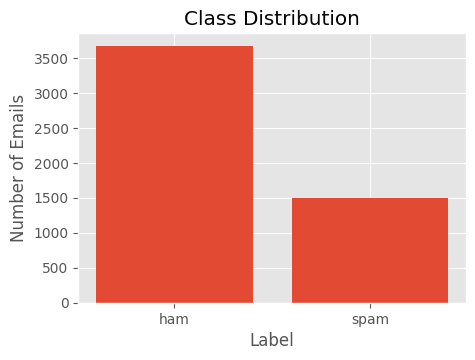

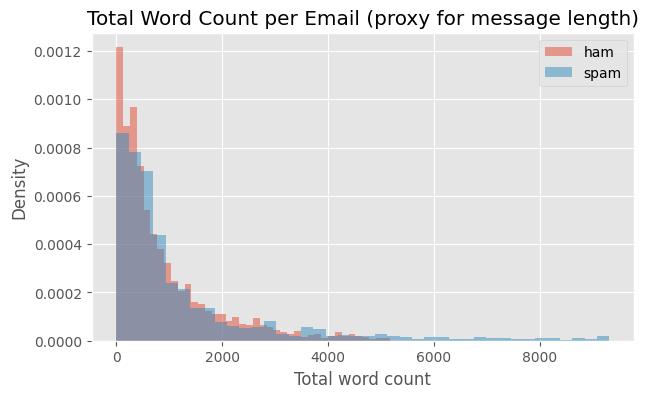

In [ ]:
# Class distribution
balance_pd = df.groupBy("label").count().toPandas()
balance_pd["label_name"] = balance_pd["label"].map({0.0: "ham", 1.0: "spam"})

plt.figure(figsize=(5, 3.5))
plt.bar(balance_pd["label_name"], balance_pd["count"])
plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Number of Emails")
plt.show()

# Total word-count distribution
length_pd = df.select("label", "total_words").toPandas()
length_pd["label_name"] = length_pd["label"].map({0.0: "ham", 1.0: "spam"})

plt.figure(figsize=(7, 4))
for lab in ["ham", "spam"]:
    subset = length_pd[length_pd["label_name"] == lab]["total_words"]
    plt.hist(subset, bins=40, alpha=0.5, density=True, label=lab, range=(0, subset.quantile(0.98)))

plt.title("Total Word Count per Email (proxy for message length)")
plt.xlabel("Total word count")
plt.ylabel("Density")
plt.legend()
plt.show()

In [ ]:
# Re-define pipeline with unique output column names to prevent collisions
# Using suffix '_vec' and '_final' to ensure uniqueness
assembler = VectorAssembler(
    inputCols=word_cols,
    outputCol="tf_features_vec"
)

idf = IDF(
    inputCol="tf_features_vec",
    outputCol="features_final"
)

nb = NaiveBayes(
    featuresCol="features_final",
    labelCol="label",
    modelType="multinomial",
    smoothing=1.0
)

pipeline = Pipeline(stages=[
    assembler,
    idf,
    nb
])

print("Pipeline updated with unique column names.")

Pipeline updated with unique column names.


In [ ]:
# Ensure we only keep the original word columns and label before splitting
# This prevents 'Column already exists' errors during pipeline fit/transform re-runs
clean_df = df.select(["label"] + word_cols)

train_df, test_df = clean_df.randomSplit([0.8, 0.2], seed=42)

print("Training records:", train_df.count())
print("Testing records :", test_df.count())

Training records: 4194
Testing records : 978


In [ ]:
# Fit the updated pipeline using the original split DataFrames
# The unique output names ('tf_features_vec', 'features_final') will avoid name clashes
model = pipeline.fit(train_df)
pred = model.transform(test_df)

print("Model trained successfully.")
pred.select("label", "prediction", "probability").show(10, truncate=False)

Model trained successfully.
+-----+----------+-----------------------------------------+
|label|prediction|probability                              |
+-----+----------+-----------------------------------------+
|0.0  |1.0       |[5.994669306802107E-15,0.999999999999994]|
|0.0  |0.0       |[1.0,5.641498565594583E-29]              |
|0.0  |0.0       |[0.9916461279701594,0.008353872029840606]|
|0.0  |0.0       |[1.0,3.1064054415955275E-63]             |
|0.0  |0.0       |[1.0,7.811548222670982E-47]              |
|0.0  |0.0       |[1.0,5.5227887327373415E-33]             |
|0.0  |0.0       |[1.0,7.337540215868482E-57]              |
|0.0  |0.0       |[1.0,4.318213763121938E-44]              |
|0.0  |0.0       |[1.0,1.9580950397695795E-59]             |
|0.0  |0.0       |[1.0,1.9580950397695795E-59]             |
+-----+----------+-----------------------------------------+
only showing top 10 rows


In [ ]:
metrics = {}
for metric_name in ["accuracy", "weightedPrecision", "weightedRecall", "f1"]:
    evaluator = MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName=metric_name
    )
    metrics[metric_name] = evaluator.evaluate(pred)

print("Baseline (Multinomial) evaluation metrics:")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

Baseline (Multinomial) evaluation metrics:
accuracy: 0.9601
weightedPrecision: 0.9619
weightedRecall: 0.9601
f1: 0.9605


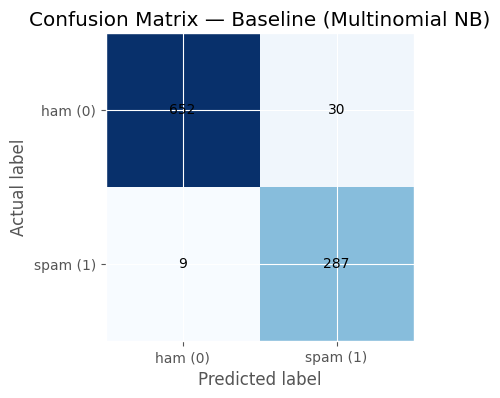

In [ ]:
# Ensure functions are imported and session is active
from pyspark.sql import functions as F

# Using standard string names for selection to see if it bypasses the active session check error
cm_pd = pred.select("label", "prediction").toPandas()

cm = confusion_matrix(cm_pd["label"], cm_pd["prediction"])
classes = ["ham (0)", "spam (1)"]

plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Blues")

for (i, j), value in np.ndenumerate(cm):
    plt.text(j, i, int(value), ha="center", va="center", color="black")

plt.xticks(range(len(classes)), classes)
plt.yticks(range(len(classes)), classes)
plt.xlabel("Predicted label")
plt.ylabel("Actual label")
plt.title("Confusion Matrix — Baseline (Multinomial NB)")
plt.show()

Baseline ROC-AUC: 0.9849


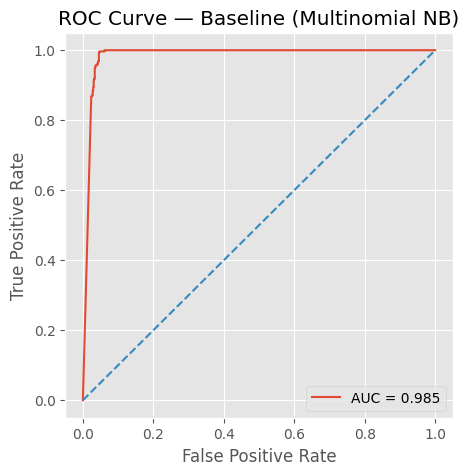

In [ ]:
pred = (
    pred
    .withColumn("prob_arr", vector_to_array(F.col("probability")))
    .withColumn("spamProb", F.col("prob_arr")[1])
)

roc_pd = pred.select("label", "spamProb").toPandas()

fpr, tpr, thresholds = roc_curve(roc_pd["label"], roc_pd["spamProb"])
roc_auc = auc(fpr, tpr)

print(f"Baseline ROC-AUC: {roc_auc:.4f}")

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Baseline (Multinomial NB)")
plt.legend()
plt.show()

In [ ]:
# Calculate total_words on the test set specifically to avoid column resolution errors
total_words_expr = F.aggregate(
    F.array(*[F.col(c) for c in word_cols]),
    F.lit(0.0),
    lambda acc, x: acc + x
)

# Add the missing column and a unique ID for identification
pred_enriched = pred.withColumn("total_words", total_words_expr) \
                    .withColumn("row_id", F.monotonically_increasing_id())

print("Top 10 most confident spam predictions:")
pred_enriched.select("row_id", "label", "prediction", "spamProb", "total_words") \
    .orderBy(F.desc("spamProb")) \
    .show(10, truncate=False)

print("Misclassified emails:")
pred_enriched.filter(F.col("label") != F.col("prediction")) \
    .select("row_id", "label", "prediction", "spamProb", "total_words") \
    .show(15, truncate=False)

Top 10 most confident spam predictions:
+----------+-----+----------+--------+-----------+
|row_id    |label|prediction|spamProb|total_words|
+----------+-----+----------+--------+-----------+
|388       |1.0  |1.0       |1.0     |568.0      |
|8589934856|0.0  |1.0       |1.0     |1697.0     |
|387       |1.0  |1.0       |1.0     |171.0      |
|8589934909|1.0  |1.0       |1.0     |231.0      |
|377       |1.0  |1.0       |1.0     |125.0      |
|8589934672|0.0  |1.0       |1.0     |166.0      |
|374       |1.0  |1.0       |1.0     |67.0       |
|8589934876|0.0  |1.0       |1.0     |2593.0     |
|378       |1.0  |1.0       |1.0     |38.0       |
|8589934841|0.0  |1.0       |1.0     |1643.0     |
+----------+-----+----------+--------+-----------+
only showing top 10 rows
Misclassified emails:
+----------+-----+----------+------------------+-----------+
|row_id    |label|prediction|spamProb          |total_words|
+----------+-----+----------+------------------+-----------+
|0         |0.0 

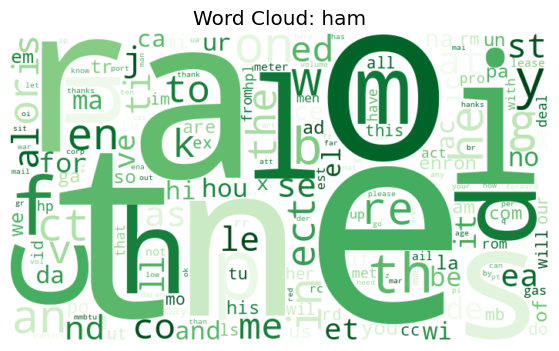

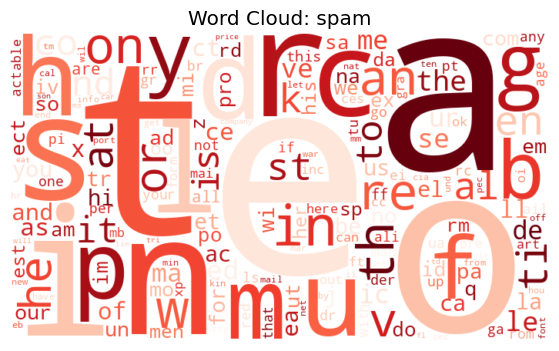

In [ ]:
word_totals = {}
for lab, name in [(0.0, "ham"), (1.0, "spam")]:
    sums = (
        df.filter(F.col("label") == lab)
        .select([F.sum(F.col(c)).alias(c) for c in word_cols])
        .collect()[0]
        .asDict()
    )
    word_totals[name] = sums

for name, cmap in [("ham", "Greens"), ("spam", "Reds")]:
    freqs = {w: int(c) for w, c in word_totals[name].items() if c and c > 0}
    wc = WordCloud(
        width=700,
        height=400,
        background_color="white",
        colormap=cmap
    ).generate_from_frequencies(freqs)

    plt.figure(figsize=(8, 4))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Word Cloud: {name}")
    plt.show()

In [ ]:
# --- Multinomial (reuse baseline pipeline/model already trained above) ---
nb_variants = {}

nb_variants["Multinomial"] = {
    "pred": pred,  # already computed in Step 8
    "model": model
}

# --- Bernoulli: binarise features AFTER IDF to ensure strict {0, 1} input ---
# The model requires binary values, so Binarizer must be the final stage before NB
idf_bern = IDF(inputCol="tf_features_vec", outputCol="idf_features")
binarizer = Binarizer(threshold=0.0, inputCol="idf_features", outputCol="features_final")
nb_bern = NaiveBayes(featuresCol="features_final", labelCol="label", modelType="bernoulli", smoothing=1.0)

pipeline_bern = Pipeline(stages=[assembler, idf_bern, binarizer, nb_bern])
model_bern = pipeline_bern.fit(train_df)
pred_bern = model_bern.transform(test_df)
nb_variants["Bernoulli"] = {"pred": pred_bern, "model": model_bern}

# --- Gaussian: same TF-IDF features as the baseline ---
nb_gauss = NaiveBayes(featuresCol="features_final", labelCol="label", modelType="gaussian")
pipeline_gauss = Pipeline(stages=[assembler, idf, nb_gauss])
model_gauss = pipeline_gauss.fit(train_df)
pred_gauss = model_gauss.transform(test_df)
nb_variants["Gaussian"] = {"pred": pred_gauss, "model": model_gauss}

print("Trained Multinomial, Bernoulli, and Gaussian Naive Bayes models.")

Trained Multinomial, Bernoulli, and Gaussian Naive Bayes models.


In [ ]:
results = []
for name, obj in nb_variants.items():
    p = obj["pred"]
    row = {"Model": name}
    for metric_name in ["accuracy", "weightedPrecision", "weightedRecall", "f1"]:
        ev = MulticlassClassificationEvaluator(
            labelCol="label", predictionCol="prediction", metricName=metric_name
        )
        row[metric_name] = ev.evaluate(p)

    p_prob = (
        p.withColumn("prob_arr", vector_to_array(F.col("probability")))
         .withColumn("spamProb", F.col("prob_arr")[1])
    )
    roc_p = p_prob.select("label", "spamProb").toPandas()
    fpr_i, tpr_i, _ = roc_curve(roc_p["label"], roc_p["spamProb"])
    row["roc_auc"] = auc(fpr_i, tpr_i)

    results.append(row)

comparison_df = pd.DataFrame(results).set_index("Model")
comparison_df

,accuracy,weightedPrecision,weightedRecall,f1,roc_auc
Model,,,,,
Multinomial,0.960123,0.961862,0.960123,0.960494,0.984926
Bernoulli,0.871166,0.870284,0.871166,0.870659,0.940279
Gaussian,0.930470,0.934931,0.930470,0.931470,0.935756


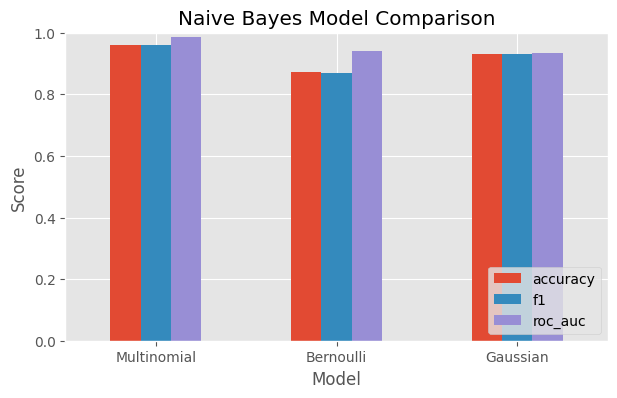

In [ ]:
comparison_df[["accuracy", "f1", "roc_auc"]].plot(
    kind="bar", figsize=(7, 4), ylim=(0, 1)
)
plt.title("Naive Bayes Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

In [ ]:
from pyspark.ml.tuning import ParamGridBuilder, TrainValidationSplit
from pyspark.ml.classification import NaiveBayes
from pyspark.ml.feature import IDF, VectorAssembler, Binarizer
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import pyspark.sql.functions as F

# IMPORTANT: If you saw 'ConnectionRefusedError', you MUST go to
# Runtime > Restart session before running this to clear the crashed JVM.

try:
    # 1. Re-initialize Spark Session (necessary after a restart)
    from pyspark.sql import SparkSession
    spark = SparkSession.builder.getOrCreate()

    # 2. Identify the best model type
    best_model_name = comparison_df["f1"].idxmax()
    print(f"Tuning the best-performing model type: {best_model_name}")

    model_type_map = {"Multinomial": "multinomial", "Bernoulli": "bernoulli", "Gaussian": "gaussian"}
    best_model_type = model_type_map[best_model_name]

    # 3. Define Pipeline Stages
    tune_assembler = VectorAssembler(inputCols=word_cols, outputCol="tf_vec_tune")

    if best_model_name == "Bernoulli":
        tune_idf = IDF(inputCol="tf_vec_tune", outputCol="idf_tune")
        tune_binarizer = Binarizer(threshold=0.0, inputCol="idf_tune", outputCol="features_tune")
        tune_nb = NaiveBayes(featuresCol="features_tune", labelCol="label", modelType="bernoulli")
        tune_stages = [tune_assembler, tune_idf, tune_binarizer, tune_nb]
    else:
        tune_idf = IDF(inputCol="tf_vec_tune", outputCol="features_tune")
        tune_nb = NaiveBayes(featuresCol="features_tune", labelCol="label", modelType=best_model_type)
        tune_stages = [tune_assembler, tune_idf, tune_nb]

    tune_pipeline = Pipeline(stages=tune_stages)

    # 4. Define search grid (kept very small for stability)
    param_grid = ParamGridBuilder() \
        .addGrid(tune_nb.smoothing, [0.1, 1.0]) \
        .build()

    tune_evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")

    # 5. Use TrainValidationSplit (more memory efficient than CrossValidator)
    tvs = TrainValidationSplit(
        estimator=tune_pipeline,
        estimatorParamMaps=param_grid,
        evaluator=tune_evaluator,
        trainRatio=0.8,
        parallelism=1, # DO NOT increase parallelism on Colab with 3000 columns
        seed=42
    )

    # 6. Fit and evaluate
    print("Starting Hyperparameter Tuning... This may take 2-3 minutes.")

    # Clear any previous cache to free memory
    spark.catalog.clearCache()
    train_df.cache()

    tvs_model = tvs.fit(train_df)
    tuned_pred = tvs_model.transform(test_df)

    # Extract best parameters
    best_smoothing = tvs_model.bestModel.stages[-1]._java_obj.getSmoothing()
    print(f"Tuning completed. Best smoothing: {best_smoothing}")

except NameError as e:
    print(f"Error: Required variables are missing. Please re-run data cleaning cells. {e}")
except Exception as e:
    print(f"An error occurred during tuning: {e}")

Tuning the best-performing model type: Multinomial
Starting Hyperparameter Tuning... This may take 2-3 minutes.
Tuning completed. Best smoothing: 0.1


In [ ]:
tuned_f1 = tune_evaluator.evaluate(tuned_pred)
print(f"Tuned {best_model_name} F1-score: {tuned_f1:.4f}")

tuned_pred = (
    tuned_pred
    .withColumn("prob_arr", vector_to_array(F.col("probability")))
    .withColumn("spamProb", F.col("prob_arr")[1])
)

tuned_auc_evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="spamProb",
    metricName="areaUnderROC"
)

tuned_auc = tuned_auc_evaluator.evaluate(tuned_pred)
print(f"Tuned {best_model_name} ROC-AUC: {tuned_auc:.4f}")

Tuned Multinomial F1-score: 0.9635
Tuned Multinomial ROC-AUC: 0.9873


In [ ]:
untuned_f1 = comparison_df.loc[best_model_name, "f1"]
untuned_auc = comparison_df.loc[best_model_name, "roc_auc"]

final_comparison = pd.DataFrame({
    "Model": [f"{best_model_name} (untuned)", f"{best_model_name} (tuned)"],
    "F1-score": [untuned_f1, tuned_f1],
    "ROC-AUC": [untuned_auc, tuned_auc]
})

final_comparison

,Model,F1-score,ROC-AUC
0,Multinomial (untuned),0.960494,0.984926
1,Multinomial (tuned),0.963487,0.987324


In [ ]:
spark.stop()